# 4 - Exploraory Data Analisys (EDA)

## Overview 
1. **Economical Performance Analysis:** Understand what drives revenue, profit, and margin across time and products.
2. **Customer Behaviour & Segmentation, Pareto analysis:** Identify which customers buy most often, spend the most, and how recently they purchased.
3. **Discount & Pricing Analysis:** Evaluate how discounts and prices affect profit margins.
4. **Operational Efficiency:** Analyze how shipping modes and delivery delays influence cost and profit.
5. **Regional Insights:** See how performance differs across regions and states.
6. **Product Portfolio Performance** Understand which categories and subcategories contribute most to sales and profit.

**Goal:** extract insights, trends, and business questions.

### Load Data

In [801]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_parquet('../data/processed/03_gold_features.parquet')
print('Data loaded succesfully.')

# Load KPIs
agg_kpis = pd.read_csv('../data/processed/03_gold_aggregated_kpis.csv', index_col = 0).squeeze()
print('KPIs loaded succesfully.')

Data loaded succesfully.
KPIs loaded succesfully.


Recheck statistical summary of numerical columns

In [806]:
num_cols_to_describe = ['sales', 'quantity', 'discount', 'profit', 'delay_in_days', 'profit_margin', 'cost']
df[num_cols_to_describe].describe().T

,count,mean,std,min,25%,50%,75%,max
sales,9994.0,229.858001,623.245101,0.4440,17.28000,54.4900,209.9400,22638.4800
quantity,9994.0,3.789574,2.225110,1.0000,2.00000,3.0000,5.0000,14.0000
discount,9994.0,0.156203,0.206452,0.0000,0.00000,0.2000,0.2000,0.8000
profit,9994.0,28.656896,234.260108,-6599.9780,1.72875,8.6665,29.3640,8399.9760
delay_in_days,9994.0,3.958175,1.747567,0.0000,3.00000,4.0000,5.0000,7.0000
profit_margin,9994.0,12.031393,46.675435,-275.0000,7.50000,27.0000,36.2500,50.0000
cost,9994.0,201.201105,550.839414,0.5544,12.68820,41.6640,182.2263,24449.5584


Apply a consistent custom theme for all plots to ensure visual coherence.

In [703]:
sns.set_theme(
    style="whitegrid",         
    context="talk",    
    palette = 'colorblind',
    rc={                        
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.titleweight": "bold",
        "figure.figsize": (10, 6)
    }
)
palette = sns.color_palette('colorblind', n_colors = 12)
print('Theme set.')

Theme set.


Visualize the correlation matrix to identify relationships between numerical features.

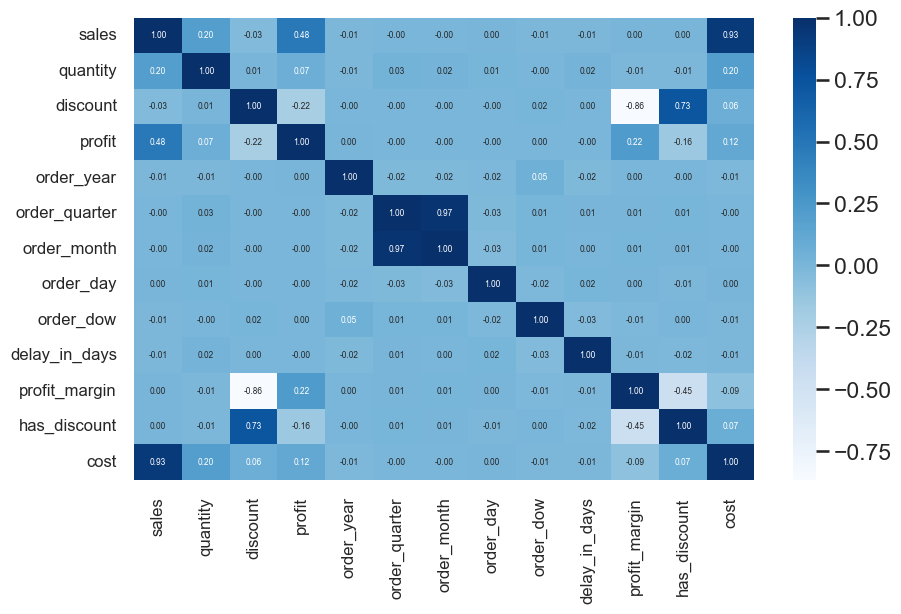

In [810]:
sns.heatmap(df[num_cols].corr(), annot = True, fmt = ".2f", annot_kws={"size": 6}, cmap = "Blues")
plt.tick_params(labelsize = 12)
plt.show()

 * Higher quantity → higher sales → higher profit.
 * Shipment delay and weekday show no linear correlation with sales or profit.
 * Profit margin is stong negatively correlated with discount.

Define a utility to save figures.

In [725]:
def save(title):
    path = f'../figures/{title.lower().replace(' ', '_').replace('-', '_').replace('.','')}.png'
    plt.savefig(path, dpi=200, bbox_inches="tight", facecolor="white", transparent=False)
    print(f'Figure saved under the path "{path}"')

### 1. Economical Performance Analysis

Figure saved under the path "../figures/sales_trend_over_time.png"


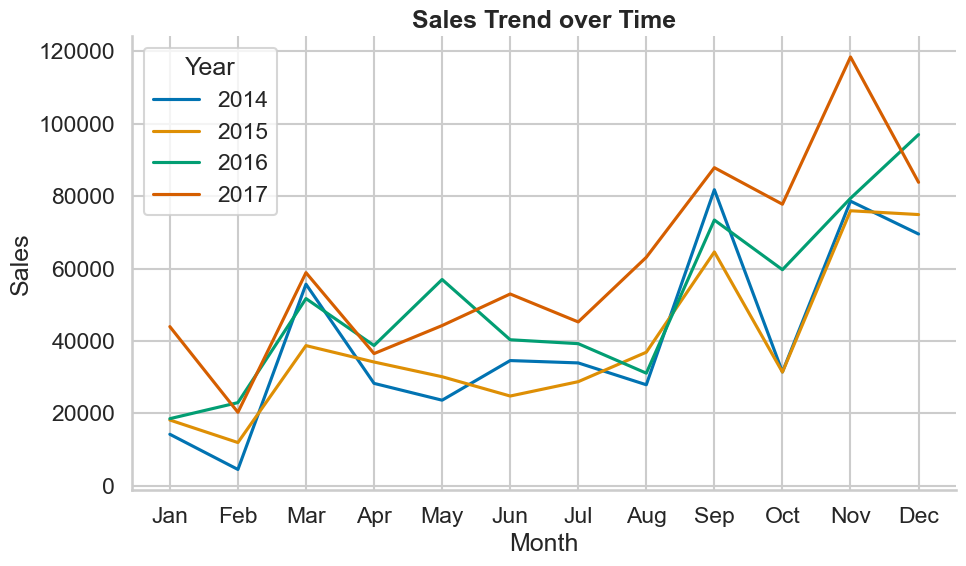

In [727]:
import calendar 

sales_trend = pd.DataFrame(df.groupby(['order_year','order_month']).sales.sum()).reset_index()

sns.lineplot(data = sales_trend, x = 'order_month', y = 'sales', hue = 'order_year', palette = palette)
plt.title('Sales Trend over Time')
plt.ylabel('Sales')
plt.xlabel('Month')
plt.legend(title = 'Year')

plt.xticks(ticks = np.arange(1,13), labels = calendar.month_abbr[1:])

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- Sales increase year over year.
- Clear seasonality with peaks in Mar, Sep, and Nov.  
- Slow sales in Jan–Feb, Apr-Aug, and Oct across all years.  

Figure saved under the path "../figures/profit_margin_by_month.png"


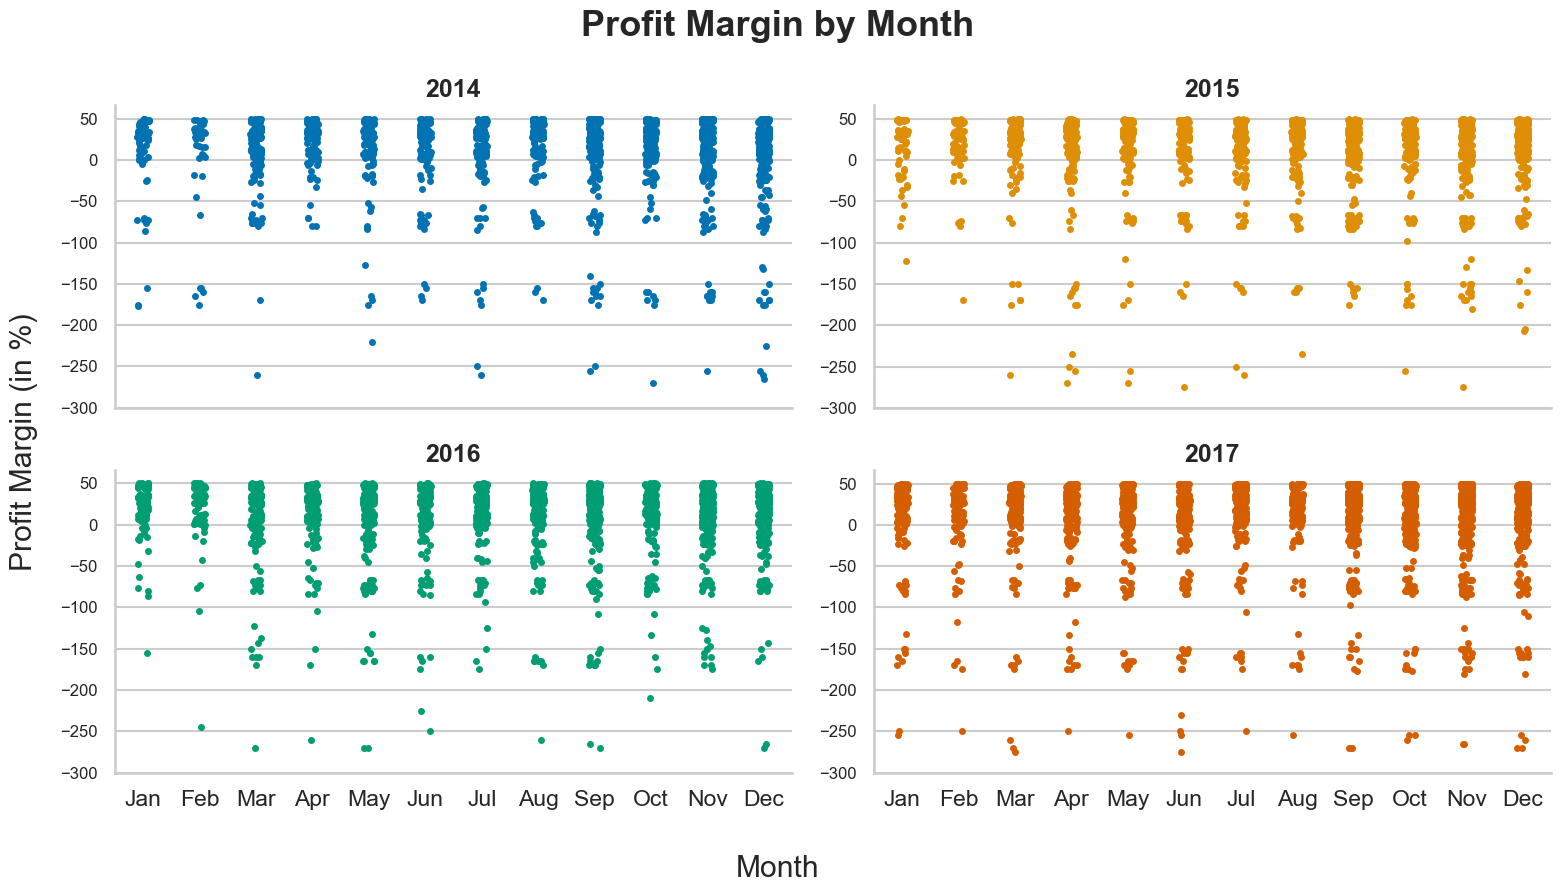

In [730]:
fig, axes = plt.subplots(2, 2, figsize = (16,9), sharex = True)
fig.suptitle('Profit Margin by Month', fontsize = 26, fontweight = 'bold')
fig.supxlabel("Month")
fig.supylabel("Profit Margin (in %)")

counter = 0
for ax in axes.flat:
    sns.stripplot(ax = ax, data = df[df.order_year == 2014 + counter], x = 'order_month', y = 'profit_margin', color = palette[counter])
    ax.set_title(str(2014 + counter))
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    
    ax.set_xticks(ticks = np.arange(0,12), labels = calendar.month_abbr[1:])
    ax.set_yticks(ticks = np.arange(50,-301,-50))
    ax.tick_params(axis='y', labelsize=12)

    counter += 1
    
plt.tight_layout()
save(fig._suptitle.get_text())
plt.show()

- No clear monthly or seasonal pattern is observed.  
- Most profit margins cluster around 0–50%, with frequent negative outliers below −100%.  
- Margin variability remains consistent over the years, indicating stable but volatile profitability.

Figure saved under the path "../figures/profitability_by_category.png"


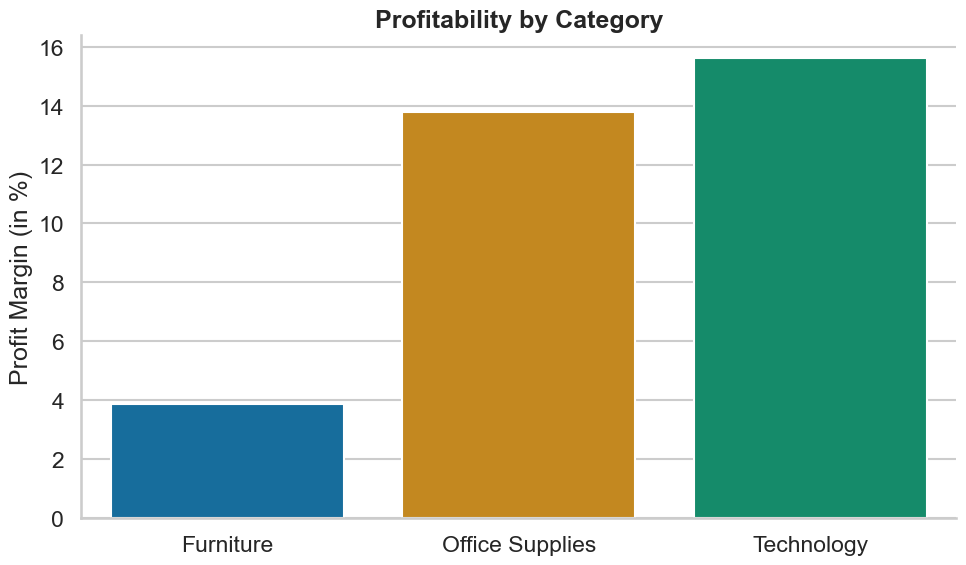

In [731]:
sns.barplot(data = df, x='category', y='profit_margin', palette = 'colorblind', errorbar = None)

plt.title("Profitability by Category")
plt.xlabel(None)
plt.ylabel('Profit Margin (in %)')

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

Figure saved under the path "../figures/profitability_by_sub_category.png"


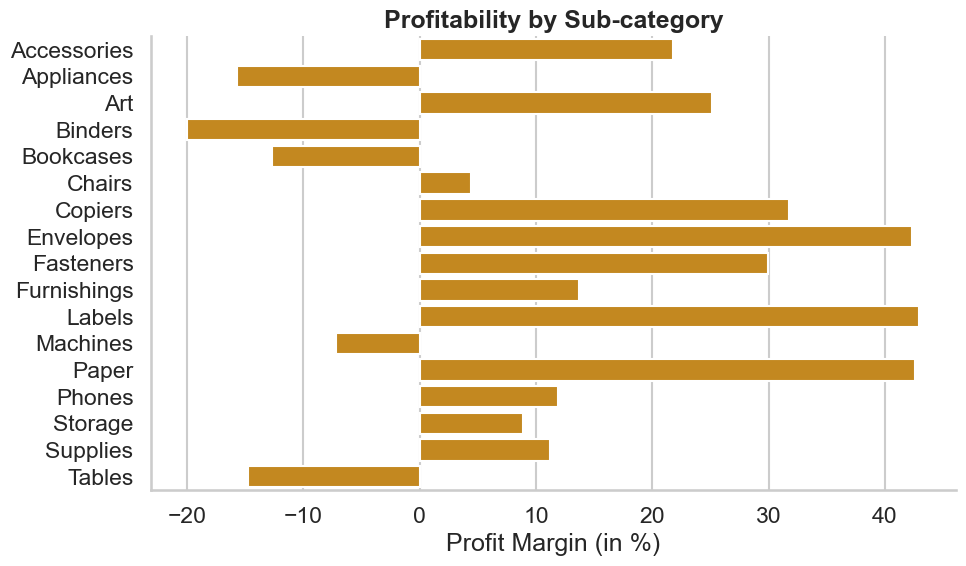

In [732]:
sns.barplot(data = df, y = 'sub_category',x = 'profit_margin', color = palette[1], errorbar = None)

plt.title("Profitability by Sub-category")
plt.ylabel(None)
plt.xlabel('Profit Margin (in %)')

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- **Highest margins:** Copiers, Envelopes, Labels, and Paper lead profitability (>30%).  
- **Lowest margins:** Tables, Machines, Bookcases, and Binders show negative or minimal profit.  
- Profitability varies widely across sub-categories, indicating uneven performance within categories.

### 2. Customer Behaviour & Segmentation, Pareto analysis

In [734]:
(df.groupby('customer_name').customer_id.nunique() > 1).astype(int).sum()

0

All names are unique, so we can use them directly as identifiers.

In [822]:
customers_summary = df.groupby('customer_name')[['profit','sales']].sum().reset_index()

Figure saved under the path "../figures/customers_with_the_highest_sales_and_their_profitability.png"


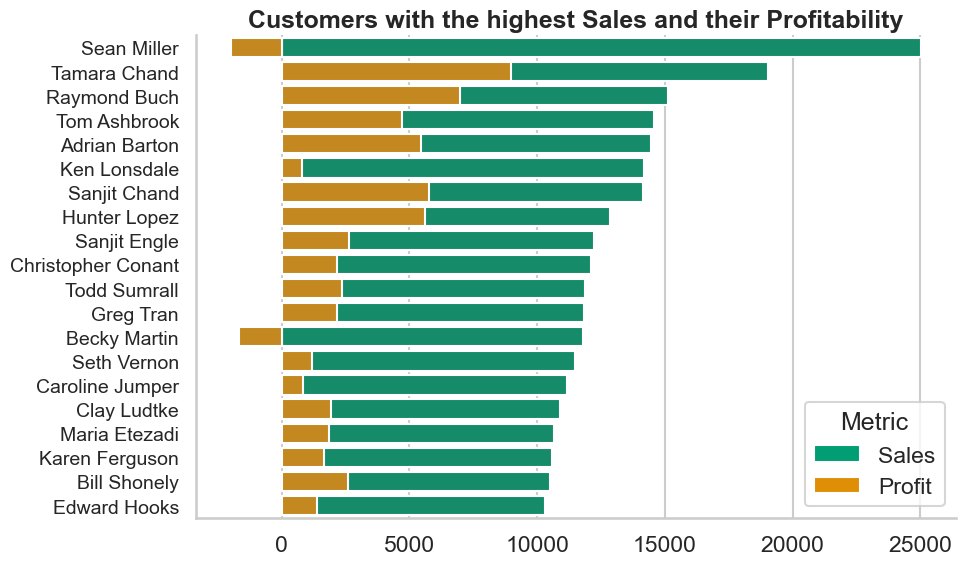

In [737]:
from matplotlib.patches import Patch

plot_data = customers_summary.sort_values('sales', ascending = False).head(20)

sns.barplot(data = plot_data, x = 'sales', y = 'customer_name', color = palette[2])
sns.barplot(data = plot_data, x = 'profit', y = 'customer_name', color = palette[1])
plt.title('Customers with the highest Sales and their Profitability')
plt.ylabel(None)
plt.xlabel(None)

#custom legend
legend = [
    Patch(facecolor=palette[2], label='Sales'),
    Patch(facecolor=palette[1], label='Profit')
]
plt.legend(handles=legend, title='Metric', loc='lower right')

plt.yticks(fontsize = 14)

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- **Sean Miller** records the highest sales but negative profit, as well as **Becky Martin**.  
- Most other top customers show both high sales and positive profits.  
- A few customers with strong sales but weak profitability may benefit from pricing or cost review.

In [738]:
# Calqualte quantile
q_sales = customers_summary.sales.quantile(q = 0.7, interpolation = 'higher')

# calculate sales and profit shares of top 30% customers by sales
top_30_sales = customers_summary[customers_summary.sales > q_sales]

sales_share = ((top_30_sales.sales.sum() / df.sales.sum()) * 100).round(2)
profit_share = ((top_30_sales.profit.sum() / df.profit.sum()) * 100).round(2)

print(f'Sales share: {sales_share}%')
print(f'Profit share: {profit_share}%')

Sales share: 60.92%
Profit share: 70.48%


- Top 30% of customers account for ~60% of sales and ~70% of profit

Figure saved under the path "../figures/the_most_profitable_customers.png"


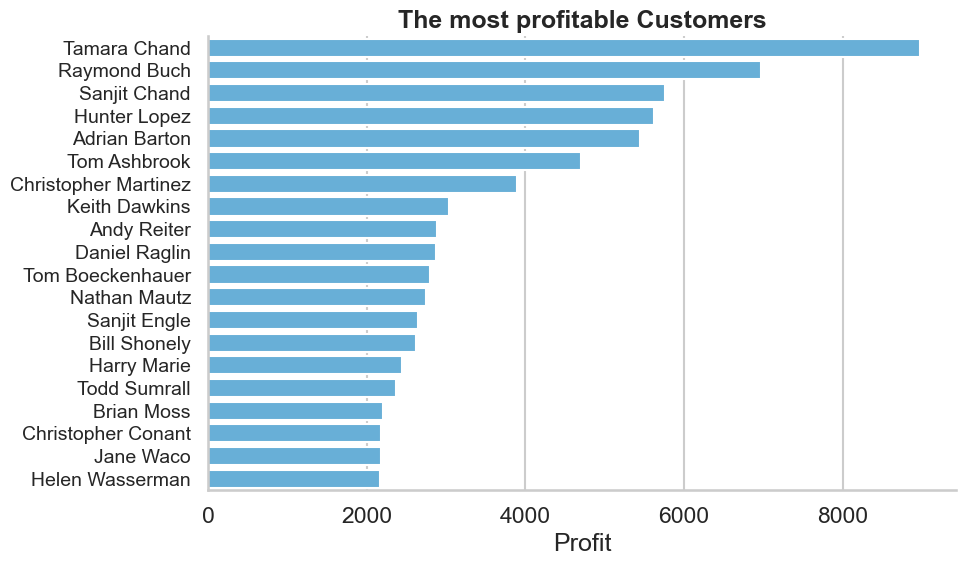

In [741]:
plot_data = customers_summary.sort_values('profit', ascending = False).head(20)
sns.barplot(data = plot_data, x = 'profit', y = 'customer_name', color = palette[9])
plt.title('The most profitable Customers')
plt.ylabel(None)
plt.xlabel('Profit')

plt.yticks(fontsize = 14)

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

In [820]:
# Calqualte quantile
q_profit = customers_summary.profit.quantile(q = 0.7, interpolation = 'higher')

# calculate profit share
top_30_profit = customers_summary[customers_summary.profit > q_profit]
profit_share = ((top_30_profit.profit.sum() / df.profit.sum()) * 100).round(2)

print(f'Profit share: {profit_share}%')

Profit share: 96.97%


-Top 30% most profitable customers occupy ~97% of profit

Figure saved under the path "../figures/the_most_unprofitable_customers.png"


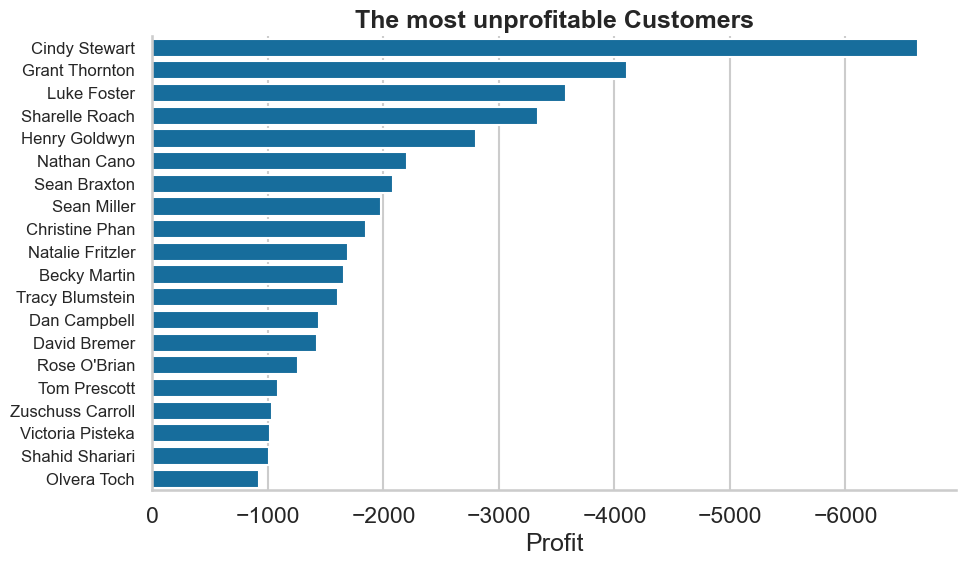

In [745]:
plot_data = customers_summary.sort_values('profit').head(20)
sns.barplot(data = plot_data, x = 'profit', y = 'customer_name', color = palette[0])
plt.title('The most unprofitable Customers')
plt.ylabel(None)
plt.xlabel('Profit')

plt.yticks(fontsize = 12)
plt.gca().invert_xaxis() 

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

In [857]:
unprofitable_customer_rate = ((customers_summary[customers_summary.profit < 0].profit.count() / customers_summary.profit.count()) * 100).round(2)
print(f"Rate of Unprofitable Customers: {negative_profit_rate}%")

Rate of Unprofitable Customers: 19.55%


Build an RFM table to quantify customer engagement and value through recency, frequency, and monetary metrics.

Figure saved under the path "../figures/average_monetary_value_by_recency_frequency_segment.png"


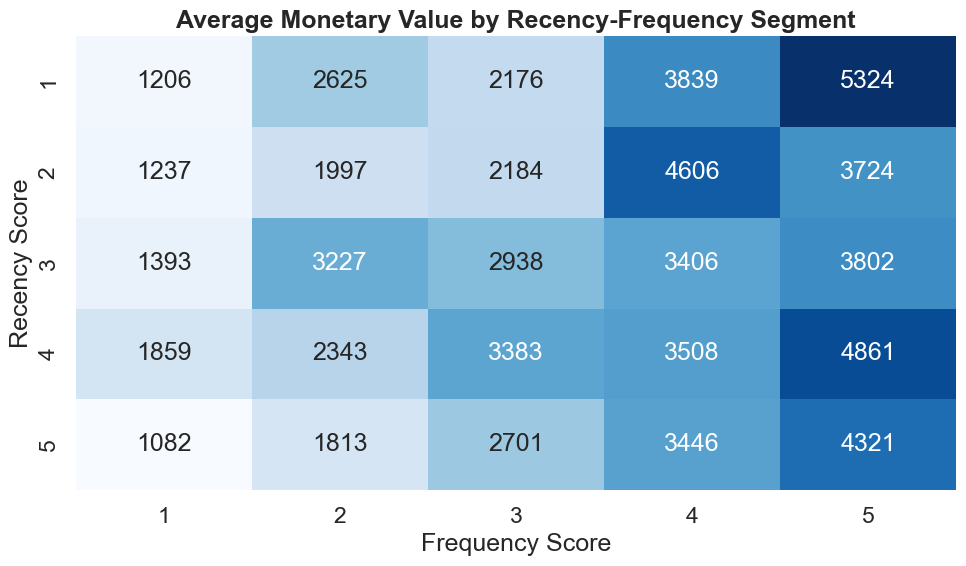

In [747]:
latest_date = df["order_date"].max() + pd.Timedelta(days=1)

# Compute RFM metrics per customer
rfm = df.groupby("customer_name").agg(
    recency_days= ("order_date", lambda x: (latest_date - x.max()).days),
    frequency= ("order_id", "nunique"),
    monetary= ("sales", "sum")
)

# Compute RFM scores
rfm["R_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5,4,3,2,1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)

# Finish Table 
rf_table = (
    rfm.groupby(["R_score", "F_score"])["monetary"]
       .mean()
)


sns.heatmap(rf_table.unstack(), cmap="Blues", annot=True, fmt=".0f", cbar = False)
plt.title("Average Monetary Value by Recency-Frequency Segment", loc = 'center')
plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

In [748]:
rf_reset = rf_table.reset_index()
corr_F_M = rf_reset.F_score.corr(rf_reset.monetary)
corr_R_M = rf_reset.R_score.corr(rf_reset.monetary)

print(f'Correlation Frequency-Monetary : {corr_F_M}')
print(f'Correlation Recency-Monetary : {corr_R_M}')

Correlation Frequency-Monetary : 0.9044328358264786
Correlation Recency-Monetary : -0.034052849233529386


- **Frequency–Monetary correlation:** Strong positive relationship; customers who purchase more frequently tend to spend more.  
- **Recency–Monetary correlation:** Almost no linear correlation; recent purchases have no direct impact on total spend.

### 3. Discount & Pricing Analysis

Figure saved under the path "../figures/discount_impact_on_profit_margin.png"


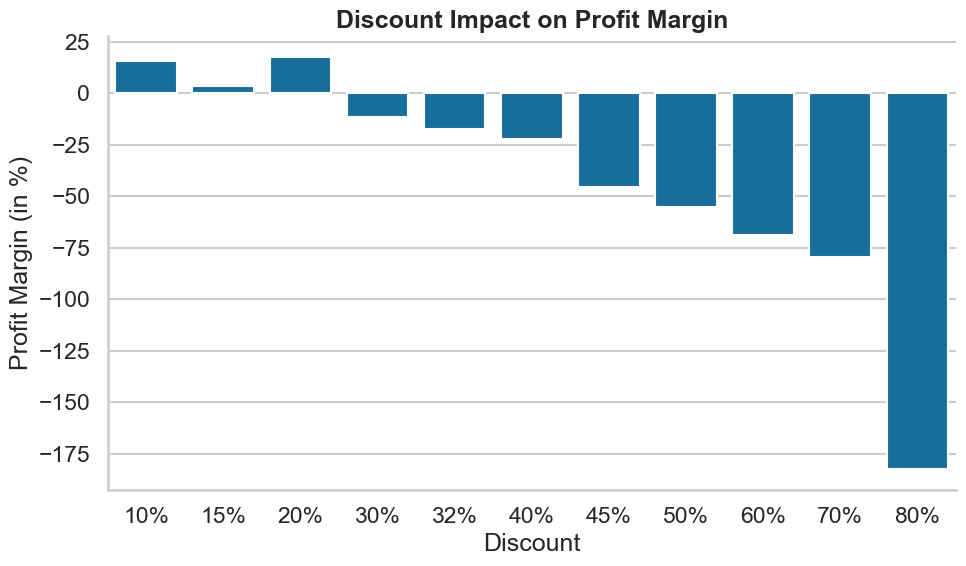

In [753]:
sns.barplot(data = df[df.discount > 0], x = 'discount', y = 'profit_margin', color = palette[0], errorbar = None)
plt.title('Discount Impact on Profit Margin')
plt.xlabel('Discount')
plt.ylabel('Profit Margin (in %)')

plt.xticks(plt.xticks()[0] , [f'{int(x * 100)}%' for x in list(np.sort(df.discount.unique()))][1:])

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- Profit margin declines sharply as discount increases.  
- Discounts above 40% lead to substantial losses, with margins turning strongly negative.  
- Moderate discounts (≤20%) maintain healthy profitability.

Figure saved under the path "../figures/profit_margin_distribution_for_discounted_vs_non_discounted_sales.png"


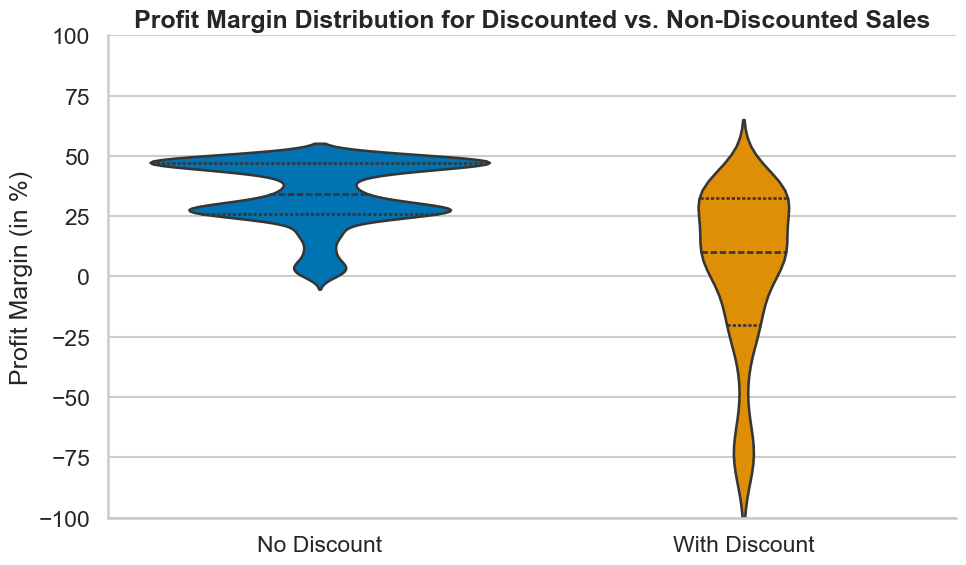

In [754]:
sns.violinplot(data = df, x='has_discount', y='profit_margin', palette = 'colorblind',\
               fill = True, saturation = 1, inner='quart', bw_method = 'silverman', common_norm  = True)
plt.title("Profit Margin Distribution for Discounted vs. Non-Discounted Sales")
plt.xlabel(None)
plt.ylabel('Profit Margin (in %)')

plt.xticks([0,1], ['No Discount', 'With Discount'])
plt.ylim(-100,100)

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- Non-discounted sales maintain consistently higher profit margins.  
- Discounted sales show a much wider spread with many negative margins.  
- Heavy discounting significantly increases profit volatility and risk of loss.

Figure saved under the path "../figures/average_discount_level_by_sub_category.png"


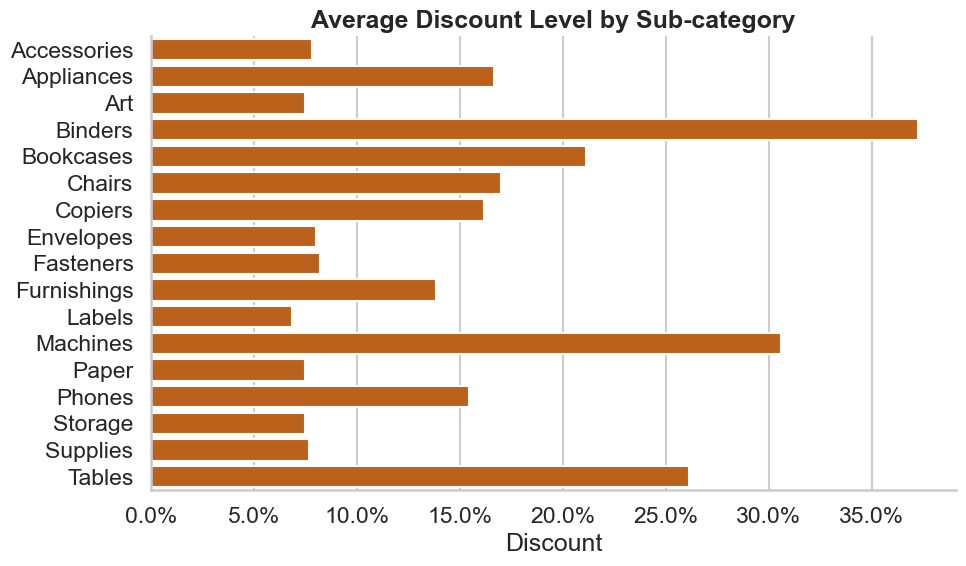

In [755]:
import matplotlib.ticker as mtick
sns.barplot(data = df, y="sub_category", x="discount", color = palette[3], ci = None)
plt.title("Average Discount Level by Sub-category")
plt.xlabel('Discount')
plt.ylabel(None)

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- **Art**, **Machines**, and **Tables** receive the highest average discounts (>25%).  
- Most other sub-categories maintain moderate discounts below 15%.  
- Excessive discounting in certain segments may be eroding profit margins.

Figure saved under the path "../figures/discount_impact_on_profit_distribution.png"


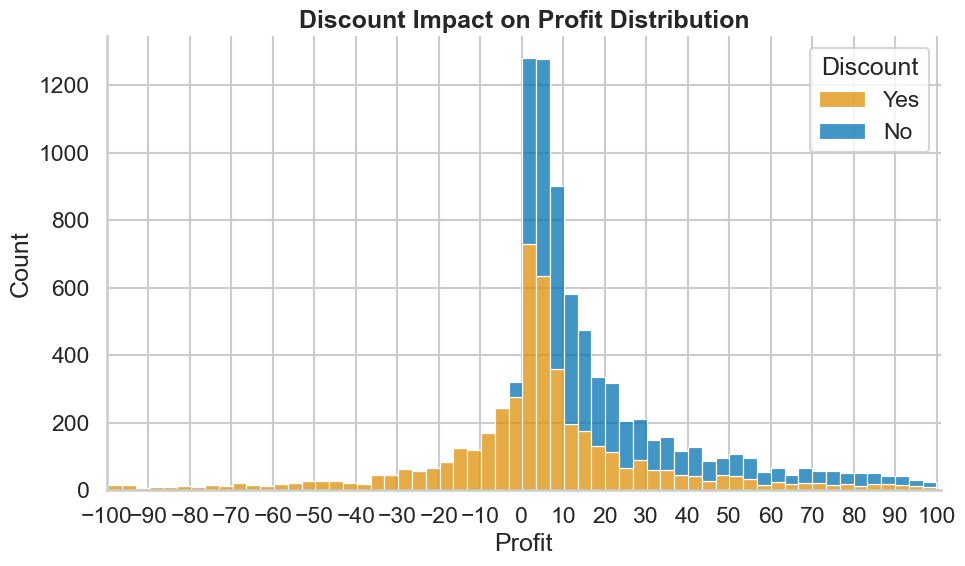

In [756]:
plot_data = df[(df.profit > -100) & (df.profit < 100)]

sns.histplot(data= plot_data, x="profit", hue="has_discount", multiple = 'stack', bins = 60, palette = 'colorblind')
plt.title('Discount Impact on Profit Distribution')
plt.xlabel('Profit')
plt.legend(title = 'Discount', labels = ["Yes", "No"])

plt.xlim(-100, 101)
plt.xticks(np.arange(-100,101,10))

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- Discounted transactions cluster around lower or negative profit values.  
- Non-discounted sales show a wider spread toward higher profits.  
- Overall, discounts significantly reduce profitability and increase the frequency of losses.

### 4. Operational Efficiency

Figure saved under the path "../figures/shipment_delay_distrubution_by_shipment_mode.png"


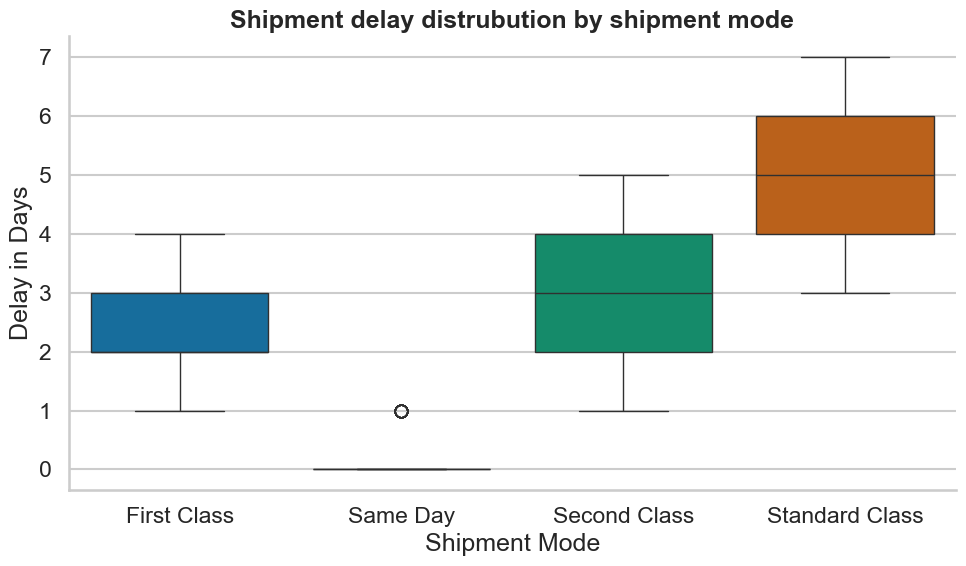

In [760]:
sns.boxplot(data = df, x='ship_mode', y='delay_in_days', palette = 'colorblind')
plt.title('Shipment delay distrubution by shipment mode')
plt.xlabel('Shipment Mode')
plt.ylabel('Delay in Days')

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- **Same Day** shipments show almost no delay, as expected.  
- **First Class** and **Second Class** have moderate delays (≈2–4 days).  
- **Standard Class** experiences the longest delays (≈4–6 days).  
- Delay patterns align with service-level expectations.

Figure saved under the path "../figures/average_profit_margin_by_shipping_mode_and_delay.png"


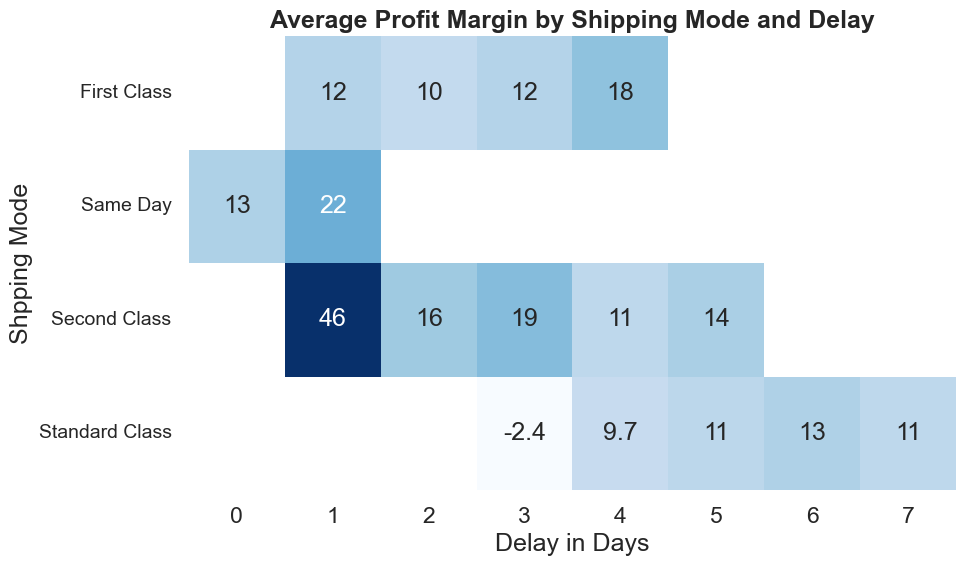

In [764]:
plot_data = df.groupby(['ship_mode', 'delay_in_days']).profit_margin.mean().unstack()

sns.heatmap(plot_data, annot = True, cmap = 'Blues', cbar = False)
plt.title('Average Profit Margin by Shipping Mode and Delay')
plt.xlabel('Delay in Days')
plt.ylabel('Shpping Mode')

plt.yticks(fontsize = 14)
plt.grid(False)

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- **Same Day** and **Second Class** shipments generally yield higher profit margins.  
- **Standard Class** shows the lowest profitability, with occasional negative margins at 3-day delays.  
- **First Class** profits remain stable regardless of delay.
- Longer delays are linked with lower margins, especially for Second Class deliveries.

### 5. Regional Insights

Figure saved under the path "../figures/average_sales_and_profit_by_region.png"


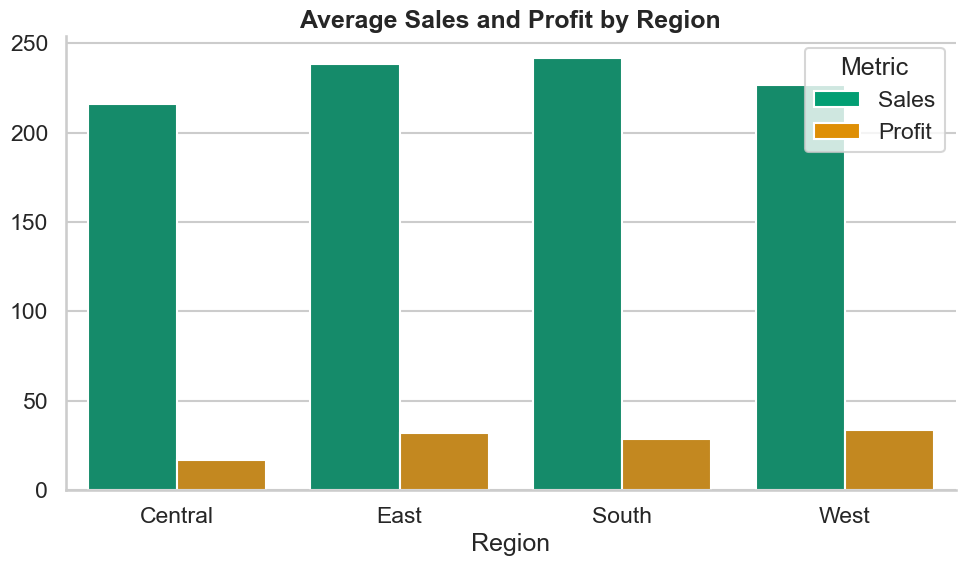

In [767]:
width = 0.4 # bar width

ax1 = sns.barplot(data = df, y = 'sales', x = 'region', color = palette[2], errorbar = None, width = width)
ax2 = sns.barplot(data = df, y = 'profit', x = 'region', color = palette[1], errorbar = None, width = width)
plt.title('Average Sales and Profit by Region')
plt.ylabel(None)
plt.xlabel('Region')

# shift bars
for p in ax1.patches[:df.region.nunique()]:        # Sales
    p.set_x(p.get_x() - width/2)
for p in ax2.patches[df.region.nunique():]:        # Profit
    p.set_x(p.get_x() + width/2)
    
#custom legend
legend = [
    Patch(facecolor=palette[2], label='Sales'),
    Patch(facecolor=palette[1], label='Profit')
]
plt.legend(handles=legend, title='Metric')

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- **East** and **South** regions record the highest average sales.
- **West** record the highest average profit.
- **Central** region lags behind in both metrics.  
- Regional profitability aligns closely with sales volume, indicating consistent efficiency across regions.

In [770]:
import plotly.express as px

# Example data (use two-letter state codes)
plot_data = df.groupby('state').profit.sum().round(2).reset_index()

fig = px.choropleth(
    plot_data,
    locations="state",
    locationmode="USA-states",
    color="profit",
    scope="usa",
    color_continuous_scale="Blues",   # any Plotly scale or custom (see below)
    labels={"profit": "Profit"},
    title="Profit by State"
)
path = '../figures/profit_by_state.html'
fig.write_html(path)
print(f'Figure saved under the path {path}')
fig

Figure saved under the path ../figures/profit_by_state.html


- **California** and **New York** are the most profitable states, generating the highest overall profit.  
- Several central and southern states show relatively low profitability.  
- Profit concentration is strongest along the **West Coast** and **Northeast** regions.

### 6. Product Portfolio Performance

Figure saved under the path "../figures/average_sales_by_sub_category.png"


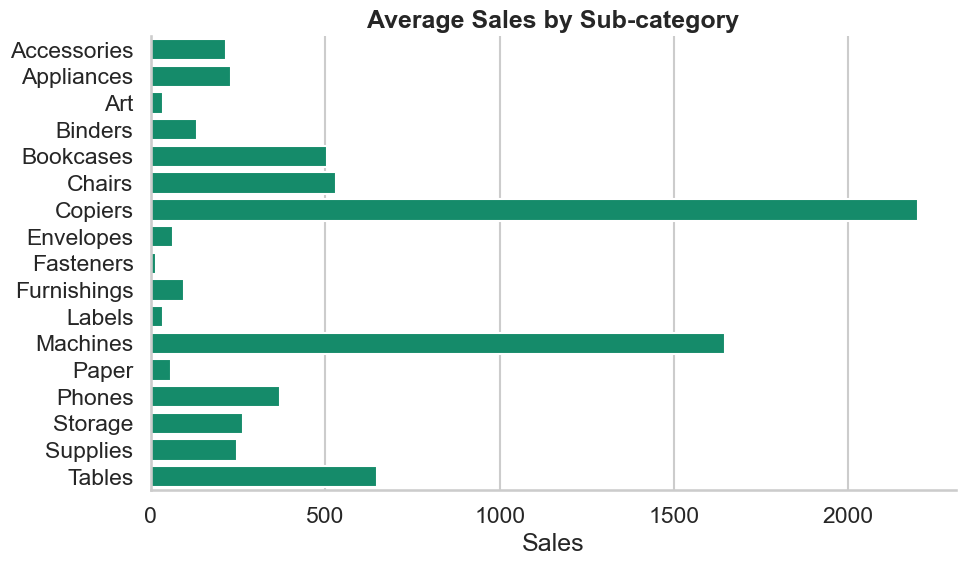

In [773]:
sns.barplot(data = df, y = 'sub_category', x = 'sales', errorbar = None, color = palette[2])
plt.title('Average Sales by Sub-category')
plt.ylabel(None)
plt.xlabel("Sales")

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

Figure saved under the path "../figures/average_profit_by_sub_category.png"


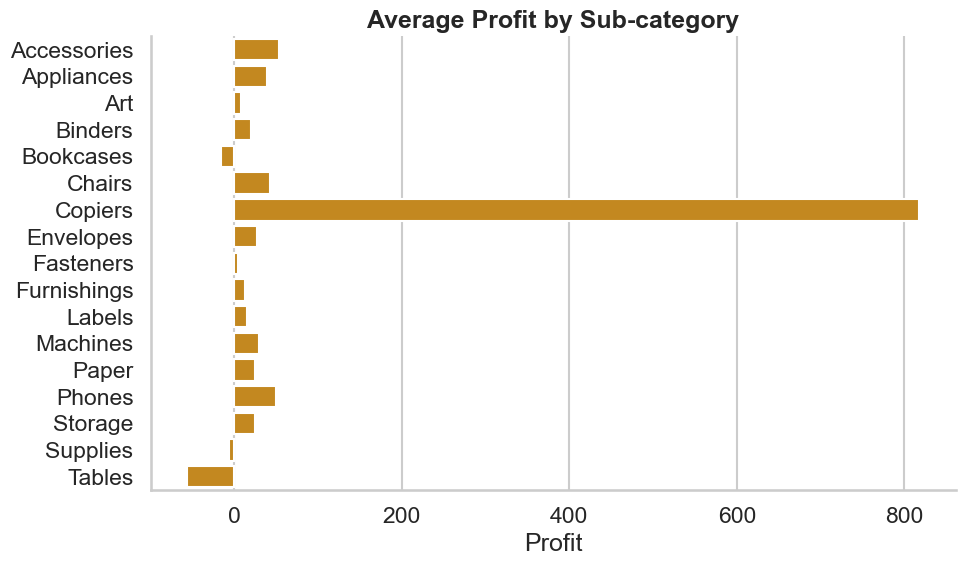

In [776]:
sns.barplot(data = df, y = 'sub_category', x = 'profit', errorbar = None, color = palette[1])
plt.title('Average Profit by Sub-category')
plt.ylabel(None)
plt.xlabel("Profit")

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- **Copiers** and **Machines** stand out with both high sales and high profits — key revenue drivers.  
- **Tables** show high sales but negative profit, signaling unprofitable performance despite strong demand.  
- Most smaller sub-categories exhibit low sales and proportionally low profits, suggesting limited business impact.  
- Overall, profitability doesn’t always scale with sales volume — highlighting areas for pricing or cost review.

Figure saved under the path "../figures/profit_margin_distribution_by_sub_category.png"


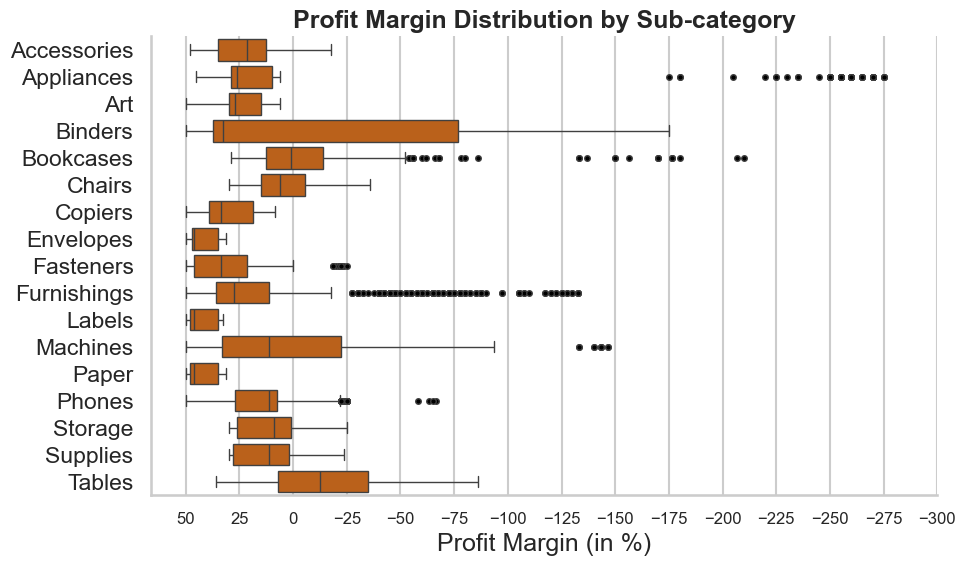

In [789]:
sns.boxplot(data = df, y='sub_category', x='profit_margin', color = palette[3],\
           flierprops=dict(marker='o', markerfacecolor='black', markersize=4))
plt.title('Profit Margin Distribution by Sub-category')
plt.ylabel(None)
plt.xlabel("Profit Margin (in %)")

plt.xticks(np.arange(-300,51,25), fontsize = 12)
plt.gca().invert_xaxis()

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- Profit margins vary widely across sub-categories, with significant outliers in several groups.  
- **Binders**, **Tables**, and **Bookcases** show large negative margins and high variability — key loss drivers.  
- **Phones**, **Art**, and **Accessories** maintain relatively stable and positive margins.  
- The broad dispersion indicates inconsistent pricing or discounting strategies across product lines.

Figure saved under the path "../figures/average_profit_margin_by_quantity_and_category.png"


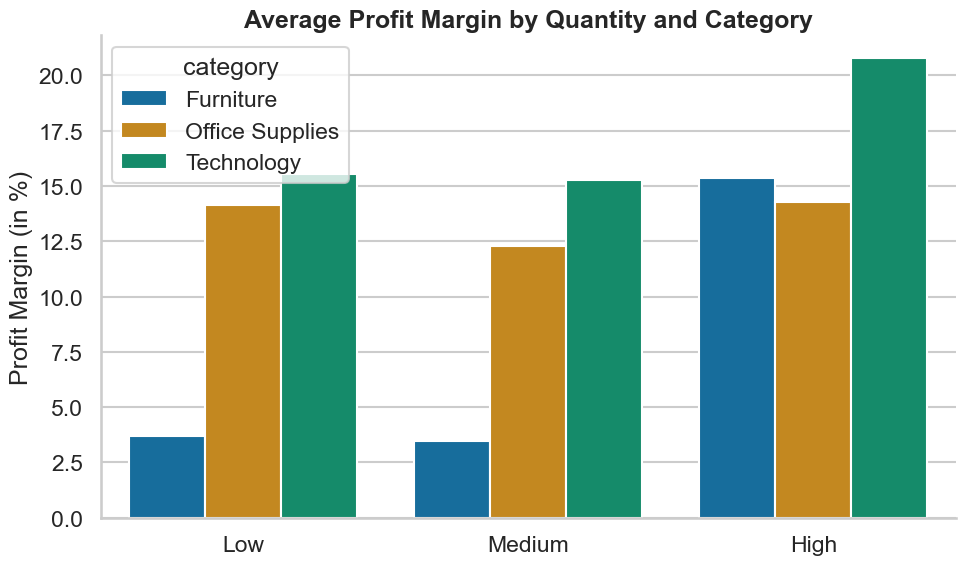

In [791]:
plot_data = df[['category', 'quantity', 'profit_margin']]
plot_data['quantity_group'] = pd.cut(plot_data['quantity'], 
                              bins=3,           
                              labels=['Low', 'Medium', 'High'])
                                     
sns.barplot(data = plot_data, x = 'quantity_group', y = 'profit_margin', hue = 'category', errorbar = None)
plt.title('Average Profit Margin by Quantity and Category')
plt.xlabel(None)
plt.ylabel("Profit Margin (in %)")

plt.tight_layout()
save(plt.gca().get_title())
plt.show()

- **Technology** consistently yields the highest profit margins across all quantity levels.  
- **Furniture** shows low margins for small and medium quantities but improves with higher quantities.  
- **Office Supplies** maintain moderate and stable margins across all quantity ranges.  
- Overall, higher quantities tend to correlate with slightly improved profitability.

A summary of this stage is documented separately in `/reports/04_eda.md`.